<a href="https://colab.research.google.com/github/zuzannagr05/lecture1/blob/main/20_04_PUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

In [ ]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [ ]:
liczba_przypadkow = len(df)
print(f"1. Całkowita liczba przypadków pacjentów: {liczba_przypadkow}")

1. Całkowita liczba przypadków pacjentów: 569


In [ ]:
liczba_zlosliwych = (df['target'] == 0).sum()
print(f"2. Liczba przypadków raka złośliwego: {liczba_zlosliwych}\n")

2. Liczba przypadków raka złośliwego: 212



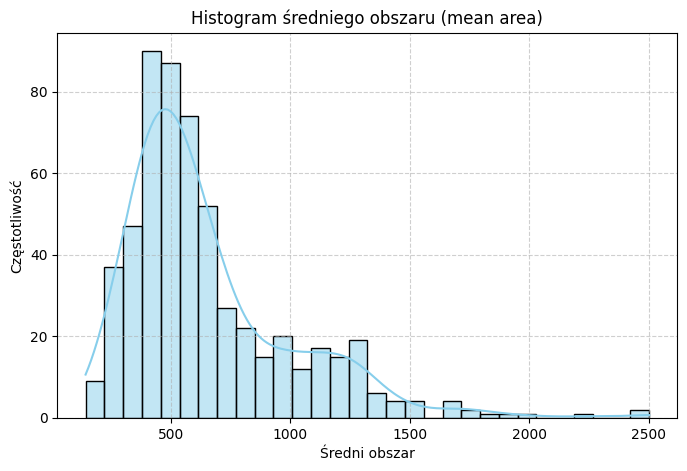

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['mean area'], kde=True, bins=30, color='skyblue')
plt.title('Histogram średniego obszaru (mean area)')
plt.xlabel('Średni obszar')
plt.ylabel('Częstotliwość')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

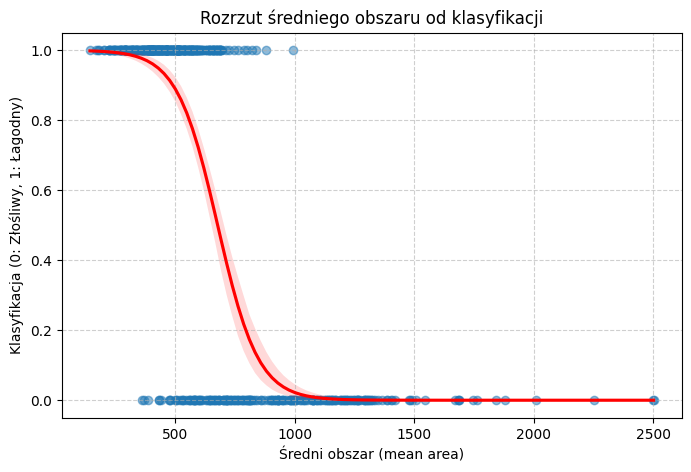

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(x='mean area', y='target', data=df, logistic=True,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Rozrzut średniego obszaru od klasyfikacji')
plt.xlabel('Średni obszar (mean area)')
plt.ylabel('Klasyfikacja (0: Złośliwy, 1: Łagodny)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_score = clf.decision_function(X_test)

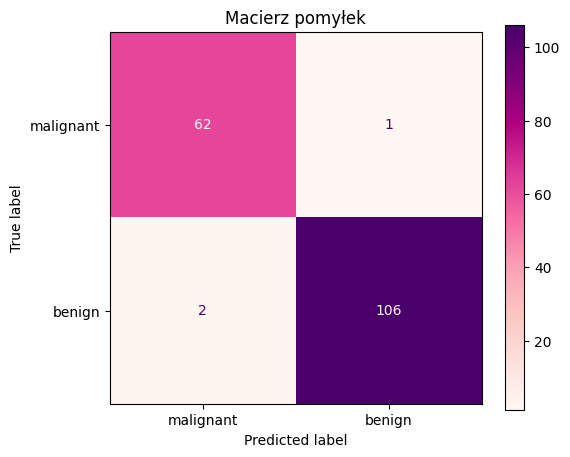

In [ ]:
# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap='RdPu')
plt.title('Macierz pomyłek')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


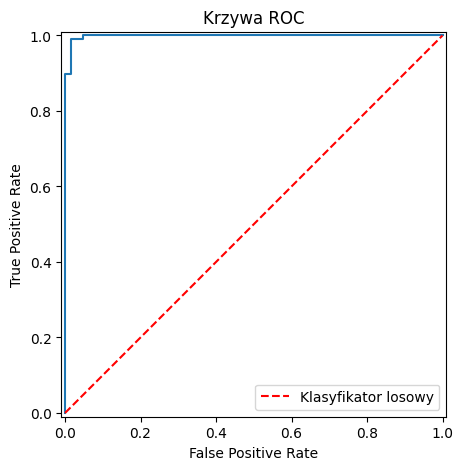

In [ ]:
# Krzywa ROC [cite: 560, 565]
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=clf.classes_[1])
fig, ax = plt.subplots(figsize=(6, 5))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_display.plot(ax=ax)

# Dodajemy linię klasyfikatora losowego do porównania (AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Klasyfikator losowy')
plt.title('Krzywa ROC')
plt.legend()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Model dla k = 5
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)

# Model dla k = 7
knn_7 = KNeighborsClassifier(n_neighbors=7)
knn_7.fit(X_train, y_train)

# Predykcje dla k = 5
y_pred_5 = knn_5.predict(X_test)
y_score_5 = knn_5.predict_proba(X_test)[:, 1]

# Predykcje dla k = 7
y_pred_7 = knn_7.predict(X_test)
y_score_7 = knn_7.predict_proba(X_test)[:, 1]

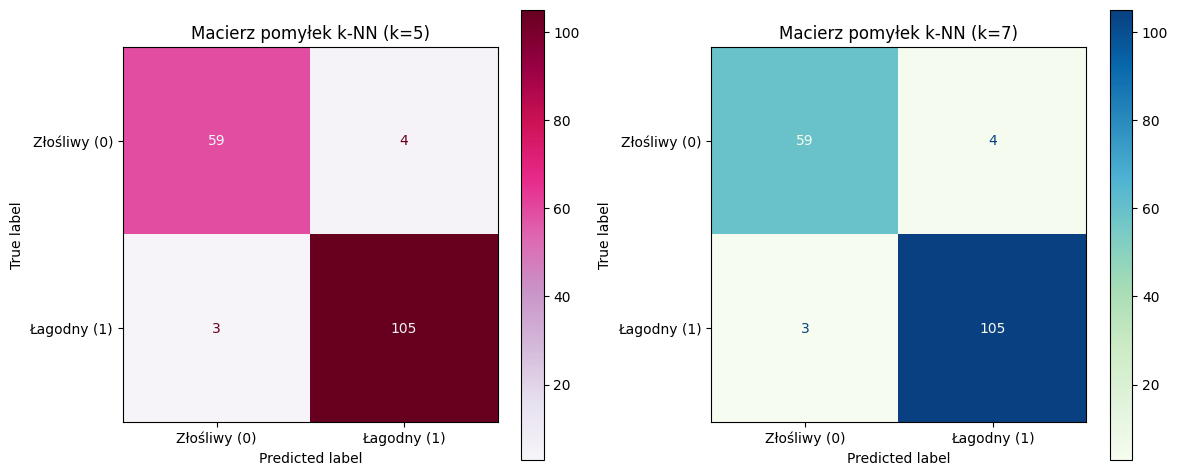

In [ ]:
# Rysowanie macierzy pomyłek (Confusion Matrix)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Macierz dla k=5
cm_5 = confusion_matrix(y_test, y_pred_5)
disp_5 = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=['Złośliwy (0)', 'Łagodny (1)'])
disp_5.plot(ax=ax1, cmap='PuRd')
ax1.set_title('Macierz pomyłek k-NN (k=5)')

# Macierz dla k=7
cm_7 = confusion_matrix(y_test, y_pred_7)
disp_7 = ConfusionMatrixDisplay(confusion_matrix=cm_7, display_labels=['Złośliwy (0)', 'Łagodny (1)'])
disp_7.plot(ax=ax2, cmap='GnBu')
ax2.set_title('Macierz pomyłek k-NN (k=7)')

plt.tight_layout()
plt.show()

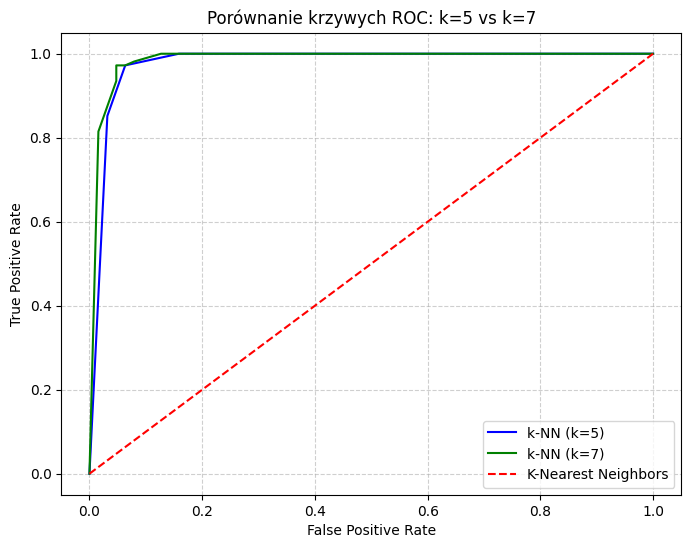

In [ ]:
# Rysowanie krzywych ROC na jednym wykresie
fpr_5, tpr_5, _ = roc_curve(y_test, y_score_5)
fpr_7, tpr_7, _ = roc_curve(y_test, y_score_7)

plt.figure(figsize=(8, 6))
plt.plot(fpr_5, tpr_5, label='k-NN (k=5)', color='blue')
plt.plot(fpr_7, tpr_7, label='k-NN (k=7)', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='K-Nearest Neighbors')

plt.title('Porównanie krzywych ROC: k=5 vs k=7')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

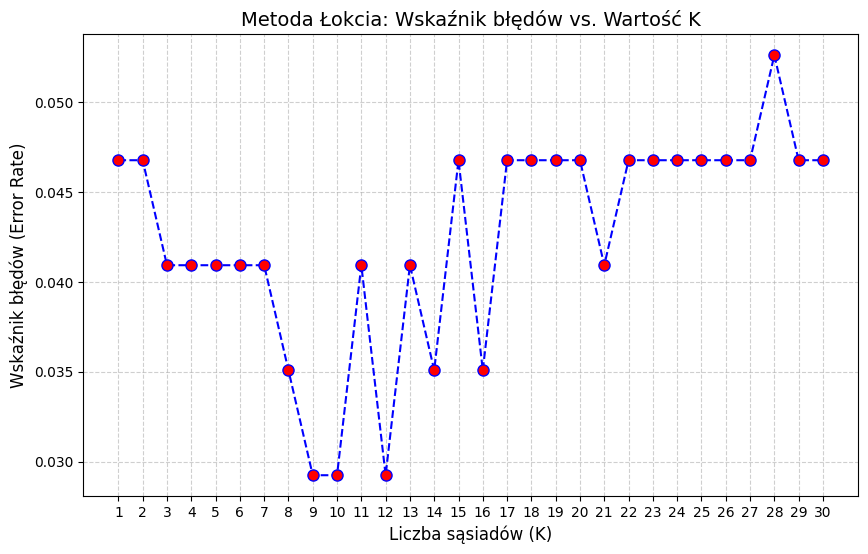

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Przygotowujemy listę na błędy
error_rates = []

# Sprawdzimy wartości K od 1 do 20
k_range = range(1, 31)

for i in k_range:
    # Trenujemy model dla danego k
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    # Przewidujemy wyniki dla zbioru testowego
    pred_i = knn.predict(X_test)

    # Obliczamy wskaźnik błędów: średnia ilość przypadków, gdzie predykcja != y_test
    error_rate = np.mean(pred_i != y_test)
    error_rates.append(error_rate)

# Rysujemy wykres
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Metoda Łokcia: Wskaźnik błędów vs. Wartość K', fontsize=14)
plt.xlabel('Liczba sąsiadów (K)', fontsize=12)
plt.ylabel('Wskaźnik błędów (Error Rate)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

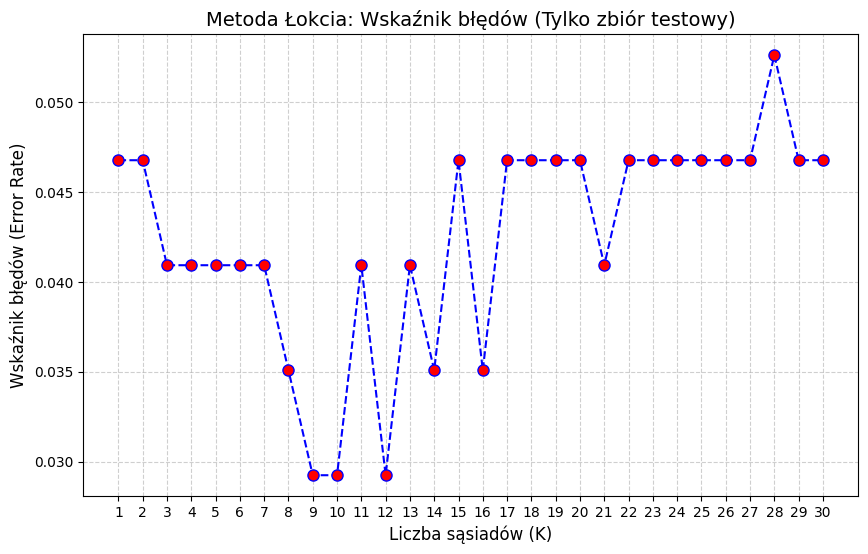

In [ ]:
# Zbiór testowy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Przygotowujemy listę tylko na błędy testowe
test_error_rates = []
k_range = range(1, 31)

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    pred_test_i = knn.predict(X_test)

    # Obliczamy wskaźnik błędów dla zbioru testowego
    error_rate = np.mean(pred_test_i != y_test)
    test_error_rates.append(error_rate)

# Rysujemy wykres
plt.figure(figsize=(10, 6))
plt.plot(k_range, test_error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

plt.title('Metoda Łokcia: Wskaźnik błędów (Tylko zbiór testowy)', fontsize=14)
plt.xlabel('Liczba sąsiadów (K)', fontsize=12)
plt.ylabel('Wskaźnik błędów (Error Rate)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Inicjalizacja i trening modelu drzewa decyzyjnego
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Predykcje dla zbioru testowego
y_pred_dt = dt_clf.predict(X_test)
y_score_dt = dt_clf.predict_proba(X_test)[:, 1] # Prawdopodobieństwo klasy pozytywnej

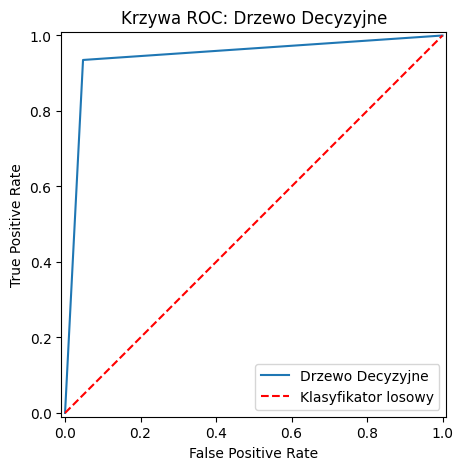

In [ ]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
fig, ax = plt.subplots(figsize=(6, 5))
roc_display_dt = RocCurveDisplay(fpr=fpr_dt, tpr=tpr_dt)
roc_display_dt.plot(ax=ax, name='Drzewo Decyzyjne')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Klasyfikator losowy')
plt.title('Krzywa ROC: Drzewo Decyzyjne')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Inicjalizacja i trening modelu lasu losowego
rf_clf = RandomForestClassifier(n_estimators=15, random_state=42)
rf_clf.fit(X_train, y_train)

# Predykcje dla zbioru testowego
y_pred_rf = rf_clf.predict(X_test)
y_score_rf = rf_clf.predict_proba(X_test)[:, 1] # Prawdopodobieństwo klasy pozytywnej

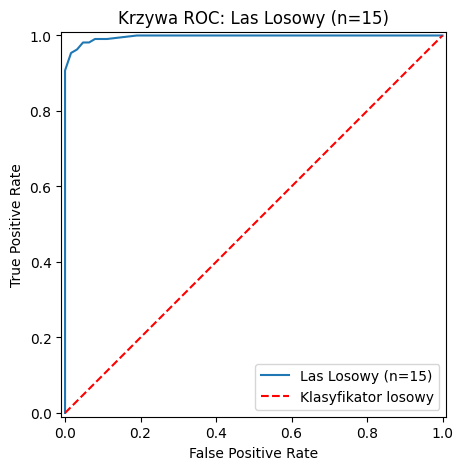

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fig, ax = plt.subplots(figsize=(6, 5))
roc_display_rf = RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf)
roc_display_rf.plot(ax=ax, name='Las Losowy (n=15)')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Klasyfikator losowy')
plt.title('Krzywa ROC: Las Losowy (n=15)')
plt.legend(loc='lower right')
plt.show()

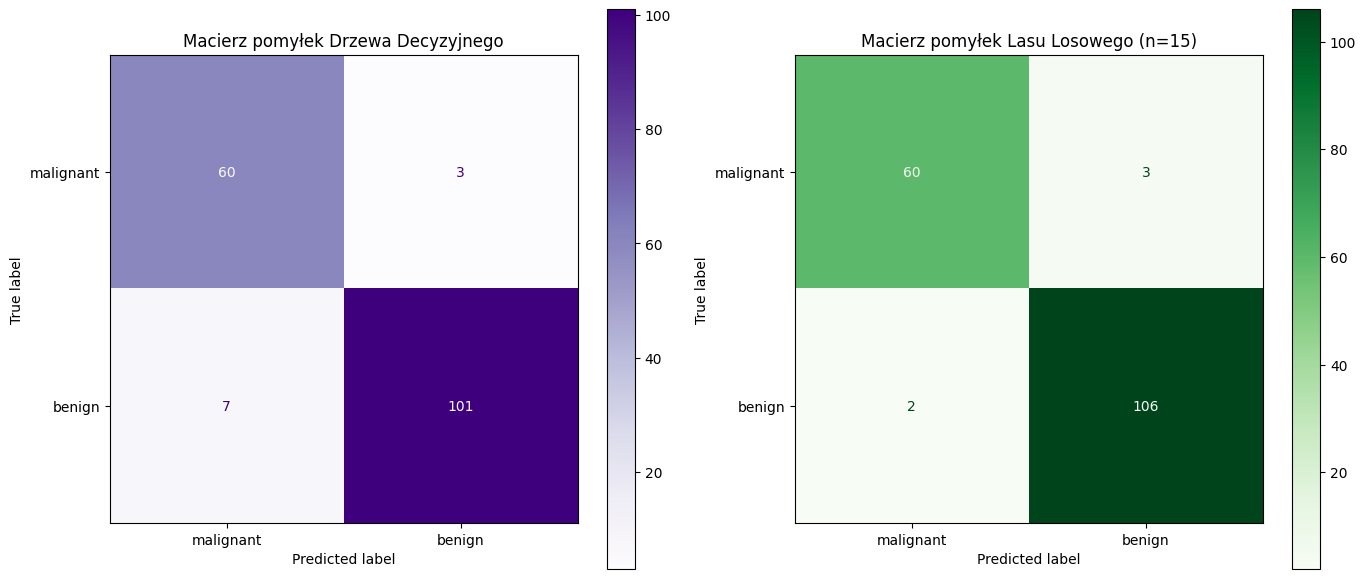

In [ ]:
# macierze pomylek
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Macierz pomyłek dla Drzewa Decyzyjnego
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=data.target_names)
disp_dt.plot(ax=ax1, cmap='Purples')
ax1.set_title('Macierz pomyłek Drzewa Decyzyjnego')

# Macierz pomyłek dla Lasu Losowego
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=data.target_names)
disp_rf.plot(ax=ax2, cmap='Greens')
ax2.set_title('Macierz pomyłek Lasu Losowego (n=15)')

plt.tight_layout()
plt.show()

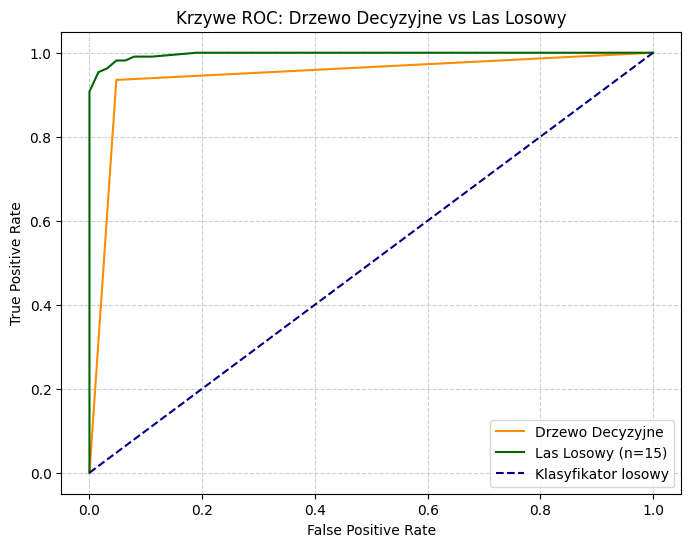

In [ ]:
#Krzywe ROC

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label='Drzewo Decyzyjne', color='darkorange')
plt.plot(fpr_rf, tpr_rf, label='Las Losowy (n=15)', color='darkgreen')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Klasyfikator losowy')

plt.title('Krzywe ROC: Drzewo Decyzyjne vs Las Losowy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()